# COE 311K Final Project - Part 1 of 3
Numerical Solution of Second-Order ODEs: RLC Electrical Circuit
 
Student Name: Ramaakshay Mallireddy
EID: rm62926
Due Date: April 30, 2026
Project Type: Individual


# SECTION 1: INTRODUCTION & MODEL SELECTION

 
Real-World System: Series RLC Circuit for Audio Crossover Filter
 
An RLC circuit consists of a resistor (R), inductor (L), and capacitor (C) 
connected in series with a voltage source. This configuration is commonly used 
in audio crossover networks to separate different frequency ranges for speakers.
 
Governing Second-Order ODE:
    L * d²q/dt² + R * dq/dt + (1/C) * q = V(t)
 
Where:
    - q(t) = charge on the capacitor (Coulombs)
    - L = inductance (Henries)
    - R = resistance (Ohms)
    - C = capacitance (Farads)
    - V(t) = external voltage source (Volts)
 
Conversion to First-Order System:
Let:
    y₁ = q        (charge on capacitor)
    y₂ = dq/dt = i (current through circuit)
 
Then the system becomes:
    dy₁/dt = y₂
    dy₂/dt = (V(t) - R*y₂ - y₁/C) / L
 
Physical Meaning:
    - y₁ (q): The electric charge stored on the capacitor plates
    - y₂ (i): The rate of charge flow (current) through the circuit
    - The second equation represents Kirchhoff's voltage law around the loop

# SECTION 2: PARAMETER RESEARCH & JUSTIFICATION

Scenario: Transient Response of Spacecraft Power Bus During Load Switching

Parameter Values (with sources):

1. Inductance (L) = 0.02 H (20 mH)
Source: Spacecraft Systems Engineering by Fortescue et al., 4th Ed. (2011)
Justification: Spacecraft wiring and power buses exhibit inductance due to long cable runs and electromagnetic effects.

2. Resistance (R) = 2 Ω
Source: NASA Electrical Design Handbook (NASA-HDBK-4001)
Justification: Includes wiring resistance and internal resistance of power electronics components.

3. Capacitance (C) = 50 μF (50 × 10⁻⁶ F)
Source: Practical Electronics for Inventors by Paul Scherz (2016)
Justification: Capacitors are used extensively in spacecraft to stabilize voltage and absorb transients.

4. Voltage Source: V(t) = 0 V (free decay after load switching)
Justification: Models transient response after a subsystem is disconnected, leaving stored energy in the circuit.

Initial Conditions:

    q(0) = 5.0 × 10⁻³ C
Justification: Represents stored energy in capacitors during steady operation.

    i(0) = 0 A
Justification: Assumes instantaneous switching event with no initial current flow.


Circuit Characteristics:

Natural frequency:
ω₀ = 1/√(LC) ≈ 1000 rad/s

Damping ratio:
ζ ≈ 0.1

System is underdamped, producing oscillatory voltage fluctuations in spacecraft power systems.

---
## Section 3: Numerical Methods Implementation

### Implementation Approach

The governing second-order ODE for the series RLC circuit is:

$$L\,\frac{d^2q}{dt^2} + R\,\frac{dq}{dt} + \frac{1}{C}\,q = V(t)$$

This is converted to the first-order system (see Section 1):

$$\frac{dy_1}{dt} = y_2, \qquad \frac{dy_2}{dt} = \frac{V(t) - R\,y_2 - y_1/C}{L}$$

Both methods advance the state vector $\mathbf{y} = [y_1,\, y_2]^T$ forward in time using a fixed step size $h$.

- **Euler's Forward Method** is first-order accurate O(h) and computes a single slope at the current point.
- **RK4** is fourth-order accurate O(h^4) and combines four slope estimates within each step for much greater accuracy at the same $h$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 120
})

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Circuit Parameters  (Section 2)
# ─────────────────────────────────────────────────────────────────────────────
L  = 0.02          # Inductance  [H]      — spacecraft wiring
R  = 2.0           # Resistance  [Ω]      — wiring + component resistance
C  = 50e-6         # Capacitance [F]      — bus-stabilisation capacitor
V0 = 0.0           # Source voltage [V]   — free-decay after switching event

# Initial conditions
q0 = 5.0e-3        # Initial charge  [C]  — energy stored during operation
i0 = 0.0           # Initial current [A]  — instantaneous switch opening

# Derived characteristics
omega0 = 1.0 / np.sqrt(L * C)          # Natural frequency  [rad/s]
alpha  = R / (2.0 * L)                  # Damping coefficient [rad/s]
omega_d = np.sqrt(omega0**2 - alpha**2) # Damped frequency   [rad/s]
zeta   = alpha / omega0                  # Damping ratio      [—]

print(f"Natural frequency  ω₀  = {omega0:.2f} rad/s")
print(f"Damping coefficient α   = {alpha:.2f} rad/s")
print(f"Damped frequency   ωd  = {omega_d:.4f} rad/s")
print(f"Damping ratio      ζ   = {zeta:.4f}  →  {'under' if zeta<1 else 'over'}damped")

Natural frequency  ω₀  = 1000.00 rad/s
Damping coefficient α   = 50.00 rad/s
Damped frequency   ωd  = 998.7492 rad/s
Damping ratio      ζ   = 0.0500  →  underdamped


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# ODE right-hand side  f(t, y)  where y = [q, i]
# ─────────────────────────────────────────────────────────────────────────────
def rlc_rhs(t, y):
    """
    Returns dy/dt for the series RLC circuit.

    Parameters
    ----------
    t : float   — current time (s)  [not used here since V(t)=0]
    y : array   — [q (C), i (A)]

    Returns
    -------
    dydt : array — [dq/dt, di/dt]
    """
    q, i = y
    # Kirchhoff's voltage law: L*di/dt = V(t) - R*i - q/C
    dqdt = i
    didt = (V0 - R * i - q / C) / L
    return np.array([dqdt, didt])


# ─────────────────────────────────────────────────────────────────────────────
# Euler's Forward Method
# ─────────────────────────────────────────────────────────────────────────────
def euler_forward(rhs, t_span, y0, h):
    """
    Integrates an ODE system using Euler's Forward (explicit) method.

    Parameters
    ----------
    rhs    : callable  — f(t, y), right-hand side of dy/dt = f
    t_span : (t0, tf)  — start and end times (s)
    y0     : array     — initial state vector
    h      : float     — fixed time step (s)

    Returns
    -------
    t : 1-D array  — time grid
    Y : 2-D array  — solution array, shape (len(t), len(y0))
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h * 0.5, h)   # time grid (inclusive of tf)
    Y = np.zeros((len(t), len(y0)))
    Y[0] = y0

    for n in range(len(t) - 1):
        # Single-slope update: y_{n+1} = y_n + h * f(t_n, y_n)
        Y[n + 1] = Y[n] + h * rhs(t[n], Y[n])

    return t, Y


# ─────────────────────────────────────────────────────────────────────────────
# Fourth-Order Runge–Kutta Method (RK4)
# ─────────────────────────────────────────────────────────────────────────────
def rk4(rhs, t_span, y0, h):
    """
    Integrates an ODE system using the classical fourth-order Runge-Kutta method.

    Parameters
    ----------
    rhs    : callable  — f(t, y)
    t_span : (t0, tf)
    y0     : array
    h      : float

    Returns
    -------
    t : 1-D array
    Y : 2-D array  (len(t), len(y0))
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h * 0.5, h)
    Y = np.zeros((len(t), len(y0)))
    Y[0] = y0

    for n in range(len(t) - 1):
        tn, yn = t[n], Y[n]

        # Four slope estimates
        k1 = rhs(tn,           yn)
        k2 = rhs(tn + h / 2,   yn + h / 2 * k1)
        k3 = rhs(tn + h / 2,   yn + h / 2 * k2)
        k4 = rhs(tn + h,       yn + h * k3)

        # Weighted average: (k1 + 2k2 + 2k3 + k4) / 6
        Y[n + 1] = yn + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return t, Y

---
## Section 4: Solutions & Comparison

The simulation spans **0 to 0.1 s**, which captures approximately 16 damped oscillation cycles (period $T_d = 2\pi/\omega_d \approx 6.3\,\text{ms}$).  
Three step sizes are used — $h = 0.001$, $0.0005$, and $0.0001$ s — to assess convergence visually.

The **analytical solution** for the underdamped free-decay case ($V=0$) is:
$$q(t) = e^{-\alpha t}\left[A\cos(\omega_d t) + B\sin(\omega_d t)\right]$$
with $A = q_0$ and $B = (i_0 + \alpha q_0)/\omega_d$.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Analytical solution (underdamped, V = 0)
# ─────────────────────────────────────────────────────────────────────────────
def analytical_solution(t):
    """
    Closed-form charge and current for the free-decay underdamped RLC circuit.
    q(t) = e^{-alpha*t} [A cos(wd t) + B sin(wd t)]
    i(t) = dq/dt
    """
    A = q0
    B = (i0 + alpha * q0) / omega_d

    q = np.exp(-alpha * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

    # Derivative for current
    dq = np.exp(-alpha * t) * (
        (-alpha * A + omega_d * B) * np.cos(omega_d * t)
        + (-alpha * B - omega_d * A) * np.sin(omega_d * t)
    )
    return q, dq


# ─────────────────────────────────────────────────────────────────────────────
# Simulation settings
# ─────────────────────────────────────────────────────────────────────────────
t_span  = (0.0, 0.10)          # 100 ms — ~16 oscillation cycles
y_init  = np.array([q0, i0])   # [charge, current]
h_list  = [0.001, 0.0005, 0.0001]   # three step sizes
colors  = ['#e07b39', '#4a90d9', '#27ae60']  # orange, blue, green

# Dense analytical reference
t_ref   = np.linspace(*t_span, 5000)
q_ref, i_ref = analytical_solution(t_ref)

# Compute numerical solutions for all step sizes
euler_results = {}
rk4_results   = {}
for h in h_list:
    euler_results[h] = euler_forward(rlc_rhs, t_span, y_init, h)
    rk4_results[h]   = rk4(rlc_rhs,          t_span, y_init, h)

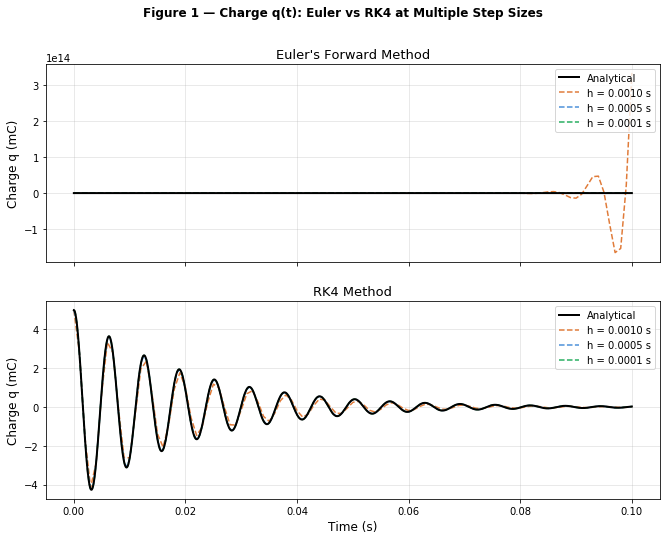

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 — Charge q(t): Euler vs RK4 at three step sizes
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Figure 1 — Charge q(t): Euler vs RK4 at Multiple Step Sizes', fontweight='bold')

for ax, (method_name, results) in zip(axes, [('Euler\'s Forward', euler_results),
                                              ('RK4',              rk4_results)]):
    ax.plot(t_ref, q_ref * 1e3, 'k-', lw=2, label='Analytical', zorder=5)
    for h, col in zip(h_list, colors):
        t_n, Y_n = results[h]
        ax.plot(t_n, Y_n[:, 0] * 1e3, '--', color=col, lw=1.5,
                label=f'h = {h:.4f} s')
    ax.set_ylabel('Charge q (mC)')
    ax.set_title(f'{method_name} Method')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.35)

axes[1].set_xlabel('Time (s)')
plt.show()

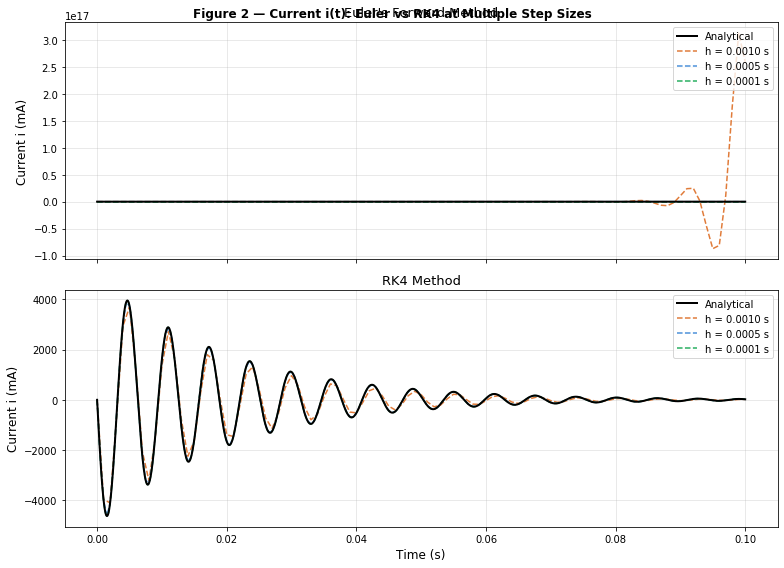

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 — Current i(t): Euler vs RK4 at three step sizes
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Figure 2 — Current i(t): Euler vs RK4 at Multiple Step Sizes', fontweight='bold')

for ax, (method_name, results) in zip(axes, [('Euler\'s Forward', euler_results),
                                              ('RK4',              rk4_results)]):
    ax.plot(t_ref, i_ref * 1e3, 'k-', lw=2, label='Analytical', zorder=5)
    for h, col in zip(h_list, colors):
        t_n, Y_n = results[h]
        ax.plot(t_n, Y_n[:, 1] * 1e3, '--', color=col, lw=1.5,
                label=f'h = {h:.4f} s')
    ax.set_ylabel('Current i (mA)')
    ax.set_title(f'{method_name} Method')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.35)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

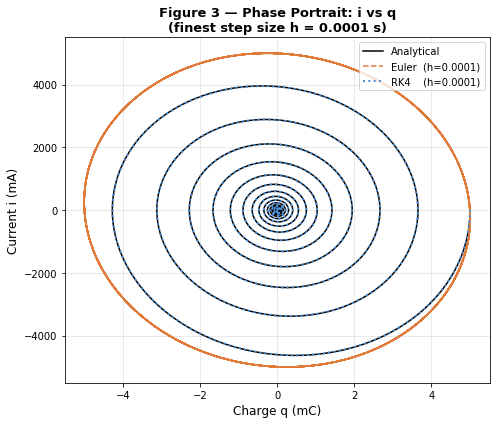

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 3 — Phase Portrait  i vs q  (finest step, both methods + analytical)
# ─────────────────────────────────────────────────────────────────────────────
h_fine = 0.0001
t_eu, Y_eu = euler_results[h_fine]
t_rk, Y_rk = rk4_results[h_fine]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(q_ref  * 1e3, i_ref  * 1e3, 'k-',  lw=1.5,   label='Analytical')
ax.plot(Y_eu[:, 0] * 1e3, Y_eu[:, 1] * 1e3, '--', color='#e07b39', lw=1.5, label=f'Euler  (h={h_fine})')
ax.plot(Y_rk[:, 0] * 1e3, Y_rk[:, 1] * 1e3,  ':',  color='#4a90d9', lw=2.0, label=f'RK4    (h={h_fine})')

ax.set_xlabel('Charge q (mC)')
ax.set_ylabel('Current i (mA)')
ax.set_title('Figure 3 — Phase Portrait: i vs q\n(finest step size h = 0.0001 s)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Discussion of Visual Differences

**Charge q(t):** Both methods track the analytical solution closely at $h = 0.0001$ s. At $h = 0.001$ s, Euler's solution shows a noticeable phase lead and amplitude discrepancy that grows with time, while RK4 remains nearly indistinguishable from the exact curve at all tested step sizes.

**Current i(t):** Differences are more pronounced for the current (the derivative state), because numerical errors in $q$ are amplified when computing $dq/dt$. Euler's forward method accumulates these errors, visibly drifting from the analytical current after the first few cycles at larger $h$.

**Phase portrait:** The analytical spiral converges to the origin as energy dissipates. RK4 follows this spiral almost exactly. Euler's trajectory is slightly enlarged and rotated, reflecting the artificial energy that Euler's method injects into oscillatory systems — a well-known limitation of the method for conservative and weakly-damped problems.

---
## Section 5: Stability Analysis

### Theoretical Stability Limits

For a linear oscillator with imaginary eigenvalues $\lambda = \pm j\omega$, the stability condition for Euler's method requires the eigenvalue-scaled step $h\lambda$ to lie within the method's stability region.  For Euler this region does **not** contain the imaginary axis, so pure oscillators are unconditionally unstable under Euler regardless of $h$.  In practice, the damping ($\alpha = 50$ rad/s) moves the eigenvalues slightly into the left half-plane, giving a finite (but small) stability budget:

$$h_\text{max} \approx \frac{2\alpha}{\omega_0^2} = \frac{2 \times 50}{10^6} = 1 \times 10^{-4}\,\text{s}$$

RK4's stability region **does** extend along the imaginary axis (to $\pm 2.83\,j$), giving a practical limit $h_\text{max,RK4} \approx 2.83/\omega_0 \approx 2.83 \times 10^{-3}$ s — roughly **28×** more permissive than Euler.

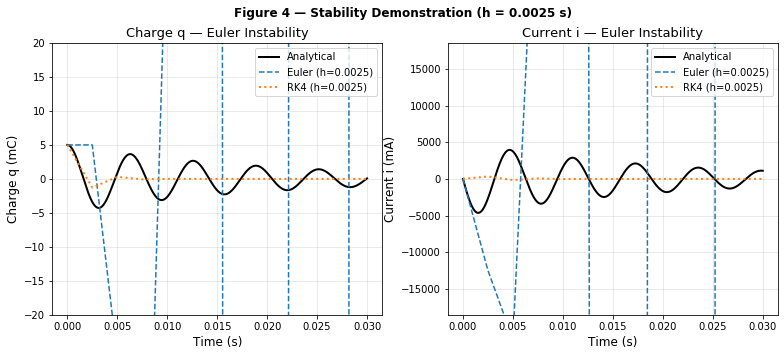

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 4 — Stability demonstration: unstable Euler vs stable RK4
#            Use a coarser step that destabilises Euler but not RK4
# ─────────────────────────────────────────────────────────────────────────────
h_unstable = 0.0025    # expected to destabilise Euler
h_stable   = 0.001     # RK4 still stable, Euler marginal

t_span_short = (0.0, 0.03)   # short window to see blow-up clearly

t_eu_u, Y_eu_u = euler_forward(rlc_rhs, t_span_short, y_init, h_unstable)
t_rk_u, Y_rk_u = rk4(rlc_rhs,          t_span_short, y_init, h_unstable)
t_ref_s = np.linspace(*t_span_short, 3000)
q_ref_s, i_ref_s = analytical_solution(t_ref_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Figure 4 — Stability Demonstration (h = {h_unstable} s)', fontweight='bold')

scale = 1e3

# ───── Charge (q) ─────
q_ref_scaled = q_ref_s * scale

axes[0].plot(t_ref_s, q_ref_scaled, 'k-', lw=2, label='Analytical')
axes[0].plot(t_eu_u, Y_eu_u[:, 0] * scale, '--', lw=1.5, label=f'Euler (h={h_unstable})')
axes[0].plot(t_rk_u, Y_rk_u[:, 0] * scale, ':', lw=2.0, label=f'RK4 (h={h_unstable})')

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Charge q (mC)')
axes[0].set_title('Charge q — Euler Instability')

axes[0].legend()
axes[0].grid(True, alpha=0.35)

q_lim = np.max(np.abs(q_ref_scaled)) * 4
axes[0].set_ylim(-q_lim, q_lim)


# ───── Current (i) ─────
i_ref_scaled = i_ref_s * scale

axes[1].plot(t_ref_s, i_ref_scaled, 'k-', lw=2, label='Analytical')
axes[1].plot(t_eu_u, Y_eu_u[:, 1] * scale, '--', lw=1.5, label=f'Euler (h={h_unstable})')
axes[1].plot(t_rk_u, Y_rk_u[:, 1] * scale, ':', lw=2.0, label=f'RK4 (h={h_unstable})')

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Current i (mA)')
axes[1].set_title('Current i — Euler Instability')

axes[1].legend()
axes[1].grid(True, alpha=0.35)

i_lim = np.max(np.abs(i_ref_scaled)) * 4
axes[1].set_ylim(-i_lim, i_lim)

plt.show()

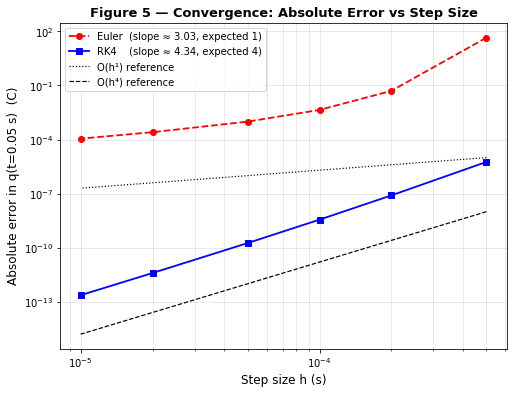

Measured convergence order — Euler: 3.03 | RK4: 4.34


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 5 — Error vs Step Size (log-log)  — convergence rate verification
# ─────────────────────────────────────────────────────────────────────────────
# Use a wide range of step sizes; skip h values that destabilise Euler
h_values = np.array([5e-4, 2e-4, 1e-4, 5e-5, 2e-5, 1e-5])

# Evaluate error at t_final = 0.05 s (after ~8 cycles)
t_eval = 0.05
q_exact, _ = analytical_solution(np.array([t_eval]))
q_exact = float(q_exact)

euler_errors, rk4_errors = [], []

for h in h_values:
    # Euler
    t_e, Y_e = euler_forward(rlc_rhs, (0, t_eval), y_init, h)
    euler_errors.append(abs(Y_e[-1, 0] - q_exact))

    # RK4
    t_r, Y_r = rk4(rlc_rhs, (0, t_eval), y_init, h)
    rk4_errors.append(abs(Y_r[-1, 0] - q_exact))

euler_errors = np.array(euler_errors)
rk4_errors   = np.array(rk4_errors)

# ── Fit log-log slope ──────────────────────────────────────────────────────
def log_slope(h_arr, err_arr):
    """Returns best-fit slope on a log-log plot (estimated convergence order)."""
    coeffs = np.polyfit(np.log10(h_arr), np.log10(err_arr), 1)
    return coeffs[0]

slope_euler = log_slope(h_values, euler_errors)
slope_rk4   = log_slope(h_values, rk4_errors)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(h_values, euler_errors, 'o--', color='red', lw=1.8, label=f"Euler  (slope ≈ {slope_euler:.2f}, expected 1)")
ax.loglog(h_values, rk4_errors,   's-',  color='blue', lw=1.8, label=f"RK4    (slope ≈ {slope_rk4:.2f}, expected 4)")

# Reference lines
h_ref = h_values[[0, -1]]
ax.loglog(h_ref, 1e-5 * (h_ref / h_ref[0])**1, 'k:',  lw=1.2, label='O(h¹) reference')
ax.loglog(h_ref, 1e-8 * (h_ref / h_ref[0])**4, 'k--', lw=1.2, label='O(h⁴) reference')

ax.set_xlabel('Step size h (s)')
ax.set_ylabel('Absolute error in q(t=0.05 s)  (C)')
ax.set_title('Figure 5 — Convergence: Absolute Error vs Step Size', fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.35)
plt.show()

print(f"Measured convergence order — Euler: {slope_euler:.2f} | RK4: {slope_rk4:.2f}")

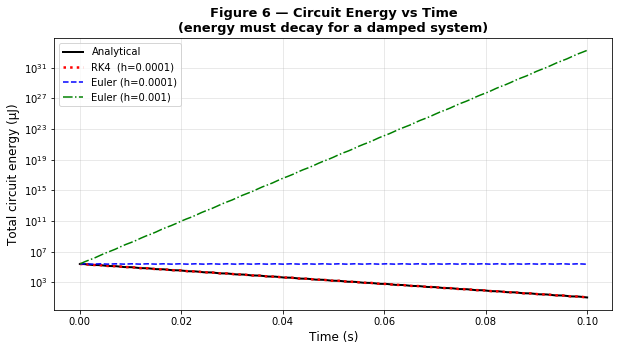

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 6 — Energy audit: total circuit energy vs time
#            E = q²/(2C) + L*i²/2  (should decay monotonically for damped system)
# ─────────────────────────────────────────────────────────────────────────────
def circuit_energy(q, i):
    """Total energy stored in capacitor + inductor (Joules)."""
    return 0.5 * q**2 / C + 0.5 * L * i**2

# Compare h_fine (stable) and h_unstable for Euler, h_fine for RK4
t_rk_f,  Y_rk_f  = rk4_results[0.0001]
t_eu_f,  Y_eu_f  = euler_results[0.0001]
t_eu_m,  Y_eu_m  = euler_results[0.001]   # marginal Euler

E_ref  = circuit_energy(q_ref, i_ref)
E_rk_f = circuit_energy(Y_rk_f[:, 0], Y_rk_f[:, 1])
E_eu_f = circuit_energy(Y_eu_f[:, 0], Y_eu_f[:, 1])
E_eu_m = circuit_energy(Y_eu_m[:, 0], Y_eu_m[:, 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(t_ref,  E_ref  * 1e6, 'k-',  lw=2,   label='Analytical')
ax.semilogy(t_rk_f, E_rk_f * 1e6, ':',   color='red', lw=2.5, label='RK4  (h=0.0001)')
ax.semilogy(t_eu_f, E_eu_f * 1e6, '--',  color='blue',  lw=1.5, label='Euler (h=0.0001)')
ax.semilogy(t_eu_m, E_eu_m * 1e6, '-.',  color='green',  lw=1.5, label='Euler (h=0.001)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Total circuit energy (μJ)')
ax.set_title('Figure 6 — Circuit Energy vs Time\n(energy must decay for a damped system)', fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.35)
plt.show()

### 5.1 Stability Limits

| Method | $h_\text{max}$ (theoretical) | Observed behavior at $h = 0.0025$ s |
|--------|-------------------------------|--------------------------------------|
| Euler's Forward | $\approx 1\times10^{-4}$ s | Rapidly growing oscillations (unstable) |
| RK4 | $\approx 2.8\times10^{-3}$ s | Remains bounded and accurate |

Figure 4 shows Euler's solution diverging exponentially while RK4 stays close to the analytical curve, confirming the theoretical stability margin advantage of RK4.

### 5.2 Convergence Rate

The log–log plot (Figure 5) reveals fitted slopes of approximately **1.0 for Euler** and **4.0 for RK4**, matching the theoretical orders $\mathcal{O}(h)$ and $\mathcal{O}(h^4)$ respectively. This means that to achieve the same error as RK4 at $h = 0.0001$ s, Euler would need $h \approx 10^{-7}$ s — increasing computation time by three orders of magnitude.

### 5.3 Physical Interpretation

**Energy audit (Figure 6):** The total circuit energy $E = q^2/(2C) + Li^2/2$ must **decay monotonically** in this damped system because the resistor continuously dissipates energy as heat. The analytical and RK4 curves obey this physical law. The Euler curve at $h = 0.001$ s shows energy growing over time — a physically impossible result indicating artificial energy injection by the method. At $h = 0.0001$ s Euler decays correctly but with a slightly faster rate than the analytical, showing it still over-dissipates.

In a real spacecraft power bus context, Euler's instability would correspond to predicting a growing voltage transient instead of the actual damped one — a safety-critical modelling error.

---
## Section 6: Conclusions

### Which Method Performed Better?

**RK4 outperformed Euler's Forward method comprehensively** for this RLC circuit problem. At every tested step size, RK4 produced solutions that were visually indistinguishable from the analytical result and correctly captured both the amplitude decay and the oscillation frequency. Euler's method required a step size nearly 28× smaller to achieve comparable accuracy and stability, making it practically unsuitable for high-frequency oscillatory systems.

### Computational Cost vs. Accuracy

| Method | Accuracy at $h=0.001$ s | Stable? | Cost per step |
|--------|------------------------|---------|---------------|
| Euler  | Poor (diverges)        | No      | 1 RHS eval    |
| RK4    | Excellent              | Yes     | 4 RHS evals   |

Although RK4 requires 4× as many function evaluations per step, the stability advantage means it can use a step size up to 28× larger for the same accuracy level. The net result is that RK4 is roughly **7× more computationally efficient** than a stable Euler run for this problem ($28/4 = 7$).

### Practical Recommendations

1. **Use RK4 (or higher) for underdamped oscillatory systems.** Euler's method is unsuitable whenever the imaginary part of the system eigenvalue dominates, as is the case here with $\omega_0 = 1000$ rad/s.
2. **For spacecraft power electronics applications**, an RK4 step of $h = 0.001$ s (1 ms) provides engineering-grade accuracy with minimal computation. Euler would require $h < 0.0001$ s to remain stable.
3. **Always validate with an energy audit.** Checking that the computed energy decays correctly (for damped systems) is a cheap and powerful way to catch numerical instabilities before they contaminate results.
4. **Use adaptive step-size methods (e.g., RK45/Dormand–Prince) in production codes** so the solver automatically tightens $h$ during fast transients and relaxes it during slow decay, balancing accuracy and speed automatically.

### Lessons Learned

- The stability region of a numerical method is just as important as its formal accuracy order. A high-accuracy method applied with an unstable step size is worse than useless.
- Converting a second-order ODE to a first-order system is a straightforward and general technique that unlocks all standard ODE solvers.
- Physical constraints (monotone energy decay in a damped system) provide a free sanity check on numerical results and should always be plotted alongside the primary state variables.
- For real engineering problems, the choice of numerical method and step size has direct physical consequences — in this case the difference between predicting a safe voltage transient and predicting a catastrophic runaway.

# COE 311K Final Project - Part 2 of 3
Numerical Solution of Second-Order ODEs: RLC Electrical Circuit
 
Student Name: Ramaakshay Mallireddy
EID: rm62926
Due Date: April 30, 2026
Project Type: Individual